In [1]:
import cartopy.crs as ccrs
import intake
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import easygems.healpix as egh

#from utils import hp_mods, plot_all_fields

In [2]:
def hp_mods(ds):
    return ds.rename({'healpix_index': 'cell'}).pipe(egh.attach_coords)

In [3]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [4]:
# Open catalog and print hk26 available models.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [5]:
# Load specific model.
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat = cat[sim]

In [6]:
# Open a 1h (2D) and 3h (3D) dataset.
# ds1h = sim_cat(zoom=8, time='PT1H').to_dask().pipe(hp_mods)
ds3h = sim_cat(zoom=8, time='PT3H').to_dask().pipe(hp_mods)

In [7]:
wam_mask = ((ds3h.lon > 340) | (ds3h.lon < 20)) & (ds3h.lat > 2) & (ds3h.lat < 15)

In [8]:
ds3h_wam = ds3h.isel(cell=wam_mask)

In [9]:
ds3h_wam

<xarray.Dataset> Size: 38GB
Dimensions:   (time: 3249, pressure: 25, cell: 9761)
Coordinates:
  * time      (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
  * pressure  (pressure) int64 200B 1 5 10 20 30 50 ... 875 900 925 950 975 1000
  * cell      (cell) int64 78kB 288253 288254 288255 ... 321539 321540 321544
    lat       (cell) float64 78kB 2.089 2.089 2.239 2.089 ... 14.94 14.94 14.94
    lon       (cell) float64 78kB 19.86 19.51 19.69 14.24 ... 343.1 343.5 342.8
    crs       int64 8B 0
Data variables: (12/14)
    cli       (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    clw       (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    hur       (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    hus       (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    orog      (cell) float64 78kB dask.array<chunksize=(9761,), meta=np.ndarray>
    qg        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    ...        ...
    sftlf     (cell) float64 78kB dask.array<chunksize=(9761,), meta=np.ndarray>
    ta        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    ua        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    va        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    wa        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
    zg        (time, pressure, cell) float32 3GB dask.array<chunksize=(16, 5, 9761), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [10]:
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile

In [11]:
for var_id, da in ds3h_wam.data_vars.items():
    if var_id == 'weights':
        continue
    print(f'{var_id:<6}: {da.attrs["standard_name"]} ({da.attrs["units"]})')

cli   : mass_fraction_of_cloud_ice_in_air (kg kg-1)
clw   : mass_fraction_of_cloud_liquid_water_in_air (kg kg-1)
hur   : relative_humidity (%)
hus   : specific_humidity (1)
orog  : surface_altitude (m)
qg    : mass_fraction_of_graupel_in_air (kg kg-1)
qr    : mass_fraction_of_rain_in_air (kg kg-1)
qs    : mass_fraction_of_snow_water_in_air (kg kg-1)
sftlf : land_area_fraction (%)
ta    : air_temperature (K)
ua    : eastward_wind (m s-1)
va    : northward_wind (m s-1)
wa    : upward_air_velocity (m s-1)
zg    : geopotential_height (m)


In [12]:
from metpy.units import units
T = ds3h_wam.ta.isel(time=0).values * units('K')

In [13]:
RH = ds3h_wam.hur.isel(time=0).values / 100 * units.dimensionless

In [14]:
Td = dewpoint_from_relative_humidity(T, RH)

/tmp/ipykernel_4198/1616097965.py:1: UserWarning: Relative humidity >120%, ensure proper units.
  Td = dewpoint_from_relative_humidity(T, RH)
/home/users/mmuetz/miniforge3/envs/hk26_env/lib/python3.14/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/users/mmuetz/miniforge3/envs/hk26_env/lib/python3.14/site-packages/metpy/calc/thermo.py:1754: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)


In [15]:
p = ds3h.pressure.values * units('hPa')

In [16]:
p[::-1]

Magnitude,[1000 975 950 925 900 875 850 800 750 700 600 500 400 300 250 200 150 100 70 50 30 20 10 5 1]
Units,hectopascal


In [17]:
Td.shape

(25, 9761)

In [18]:
n_cells = len(ds3h_wam.cell)
cape_cin_vals = []
for i, T_prof, Td_prof, p_prof in [(i, T[::-1, i], Td[::-1, i], p[::-1]) for i in range(n_cells)]:
    if i % 1000 == 0:
        print(i)

    mask = np.isnan(Td_prof.magnitude)
    if mask.sum() < 20:
        cape_cin_vals.append((np.nan * units('J/kg'), np.nan * units('J/kg')))
        continue

    prof = parcel_profile(p_prof, T_prof[0], Td_prof[0]).to('degC')
    cape_cin_vals.append(cape_cin(p_prof[mask], T_prof[mask], Td_prof[mask], prof[mask]))

0
1000
2000
3000
4000
5000
6000
7000
8000
9000


In [19]:
cape = np.array([v[0].magnitude for v in cape_cin_vals])
cin  = np.array([v[1].magnitude for v in cape_cin_vals])


In [20]:
cape

array([nan, nan, nan, ..., nan, nan, nan], shape=(9761,))

<Figure size 640x480 with 0 Axes>

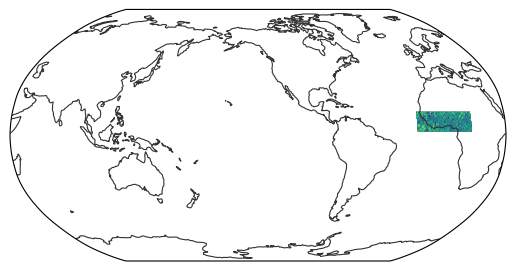

In [21]:
egh.healpix_show(ds3h_wam.wa.isel(time=0).sel(pressure=500))

In [22]:
da_cape = ds3h_wam.wa.isel(time=0).sel(pressure=500).copy().rename('cape')

In [23]:
da_cape.values = cape

<Figure size 640x480 with 0 Axes>

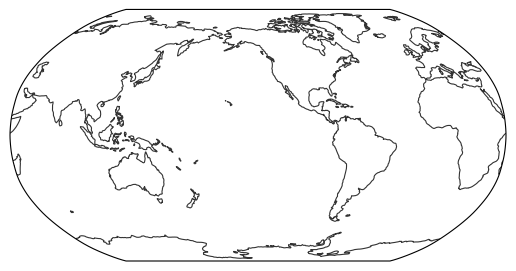

In [24]:
egh.healpix_show(da_cape)

In [25]:
import xarray as xr
ds = xr.open_dataset('cape_cin_wam.zarr/')

In [26]:
ds

<xarray.Dataset> Size: 254MB
Dimensions:  (time: 3249, cell: 9761)
Coordinates:
  * time     (time) datetime64[ns] 26kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 78kB 288253 288254 288255 ... 321539 321540 321544
    lat      (cell) float64 78kB ...
    lon      (cell) float64 78kB ...
    crs      int64 8B ...
Data variables:
    cape     (time, cell) float32 127MB ...
    cin      (time, cell) float32 127MB ...

<Figure size 640x480 with 0 Axes>

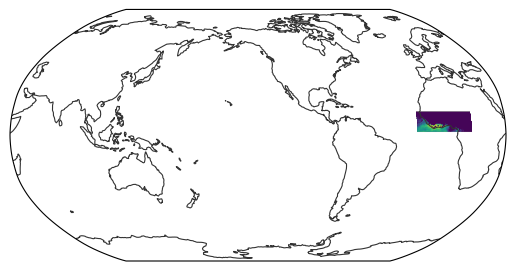

In [27]:
egh.healpix_show(ds.cape.isel(time=0))